In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('../0.dataset/dataset_serangan_jantung.csv')
df.head()

,Usia,Jenis_Kelamin,Tipe_Nyeri_Dada,Tekanan_Darah_Rest,Kolesterol,Gula_Darah_Puasa,EKG_Rest,Detak_Jantung_Max,Angina_Olahraga,Oldpeak_ST,Kemiringan_ST,Jumlah_Pembuluh_Darah,Thalassemia,BMI,Serangan_Jantung
0,67,1,2,191,169,0,1,156,0,0.5,2,1,3,31.0,0
1,80,0,3,118,152,0,0,177,0,5.2,0,0,3,32.1,1
2,57,1,0,167,407,0,1,171,0,5.3,0,0,2,26.4,1
3,43,1,1,171,222,0,1,178,1,5.2,1,0,2,34.3,1
4,71,1,0,199,161,0,1,130,1,5.0,0,2,3,29.1,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Usia                   1500 non-null   int64  
 1   Jenis_Kelamin          1500 non-null   int64  
 2   Tipe_Nyeri_Dada        1500 non-null   int64  
 3   Tekanan_Darah_Rest     1500 non-null   int64  
 4   Kolesterol             1500 non-null   int64  
 5   Gula_Darah_Puasa       1500 non-null   int64  
 6   EKG_Rest               1500 non-null   int64  
 7   Detak_Jantung_Max      1500 non-null   int64  
 8   Angina_Olahraga        1500 non-null   int64  
 9   Oldpeak_ST             1500 non-null   float64
 10  Kemiringan_ST          1500 non-null   int64  
 11  Jumlah_Pembuluh_Darah  1500 non-null   int64  
 12  Thalassemia            1500 non-null   int64  
 13  BMI                    1500 non-null   float64
 14  Serangan_Jantung       1500 non-null   int64  
dtypes: f

In [4]:
df.isnull().sum()

Usia                     0
Jenis_Kelamin            0
Tipe_Nyeri_Dada          0
Tekanan_Darah_Rest       0
Kolesterol               0
Gula_Darah_Puasa         0
EKG_Rest                 0
Detak_Jantung_Max        0
Angina_Olahraga          0
Oldpeak_ST               0
Kemiringan_ST            0
Jumlah_Pembuluh_Darah    0
Thalassemia              0
BMI                      0
Serangan_Jantung         0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
feauter_numerik = ['Usia','Tekanan_Darah_Rest','Kolesterol','Detak_Jantung_Max','Oldpeak_ST','BMI']
feature_categori = ['Jenis_Kelamin','Tipe_Nyeri_Dada','Gula_Darah_Puasa','EKG_Rest','Angina_Olahraga',
                    'Kemiringan_ST','Jumlah_Pembuluh_Darah','Thalassemia','Serangan_Jantung']

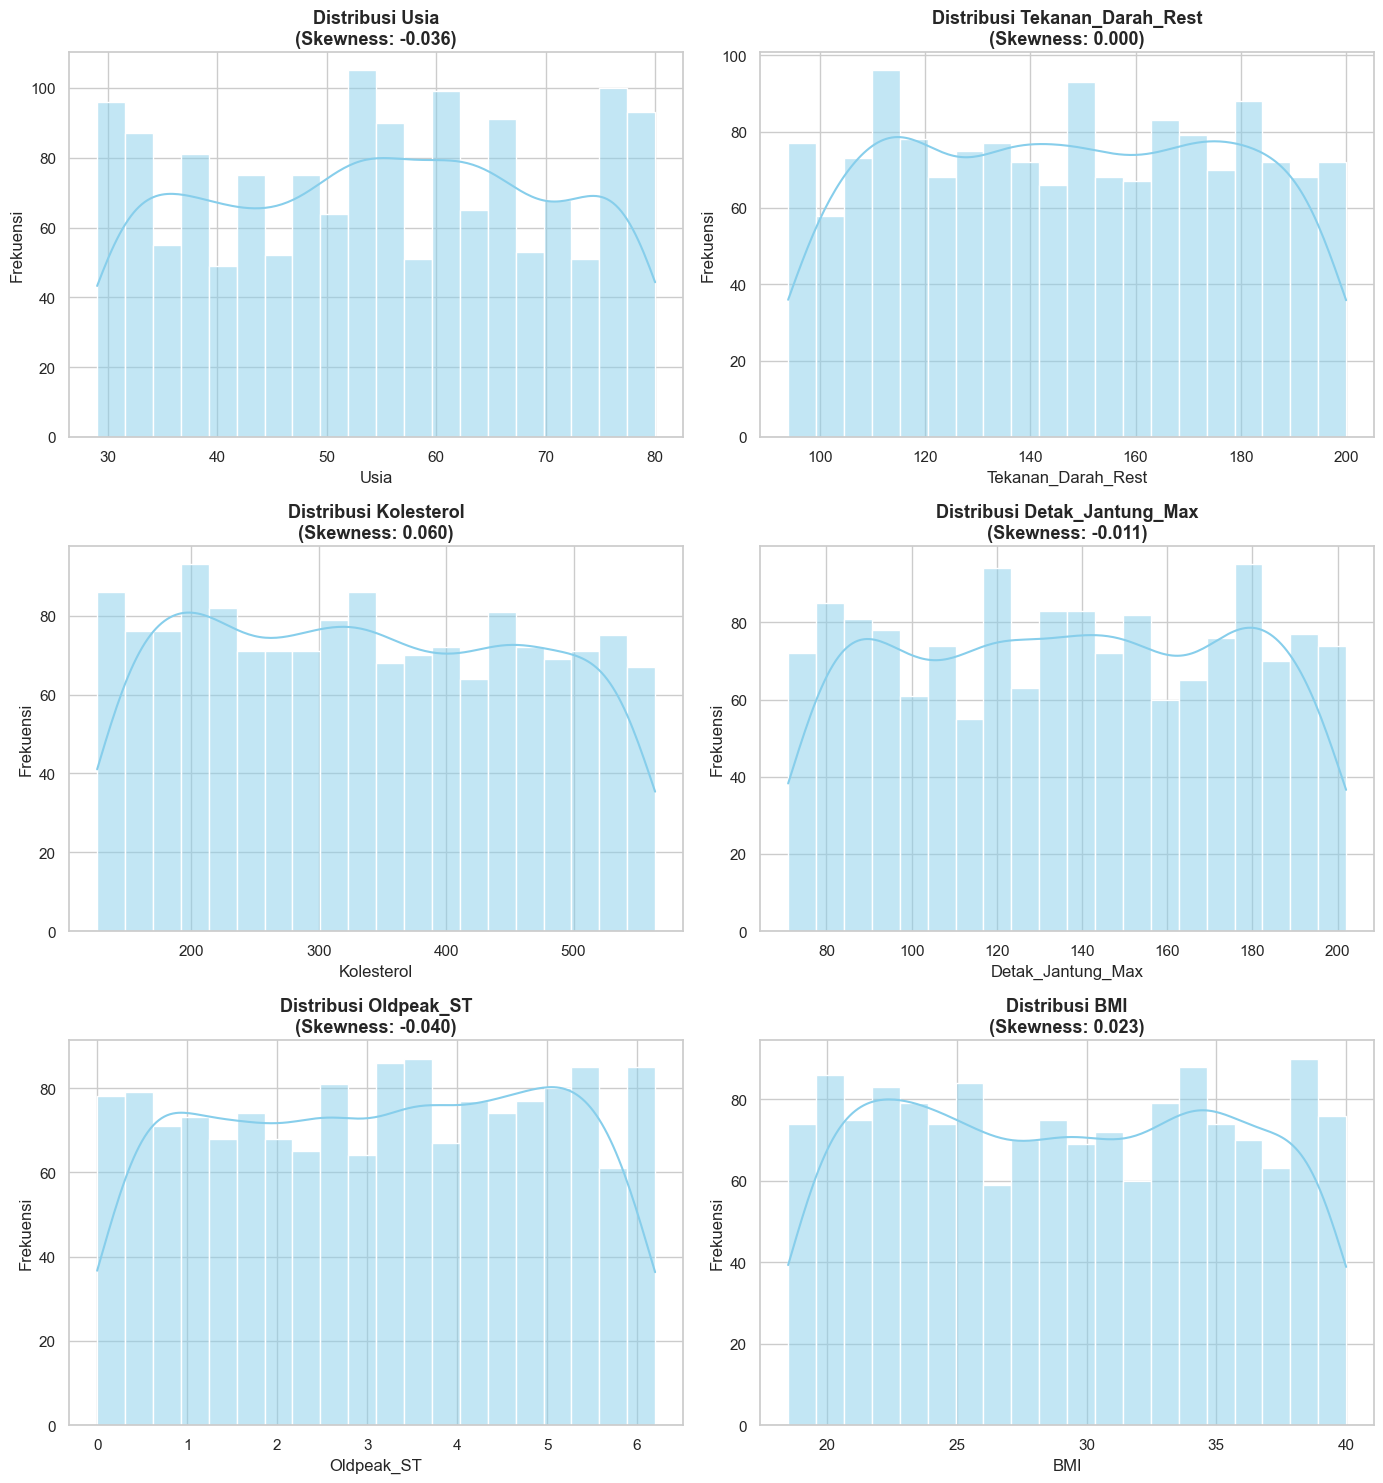

In [7]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()  # Mengubah matriks axes menjadi array 1 dimensi agar mudah di-loop
# elakukan looping untuk menggambar histogram pada setiap fitur numerik
for i, feature in enumerate(feauter_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature], ax=axes[i], kde=True, color="skyblue", bins=20)
    axes[i].set_title( f"Distribusi {feature}\n(Skewness: {feat_skew:.3f})",fontsize=13,fontweight="bold")
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Frekuensi", fontsize=12)
# engatur tata letak agar tidak tumpang tindih dan menyimpan gambar
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

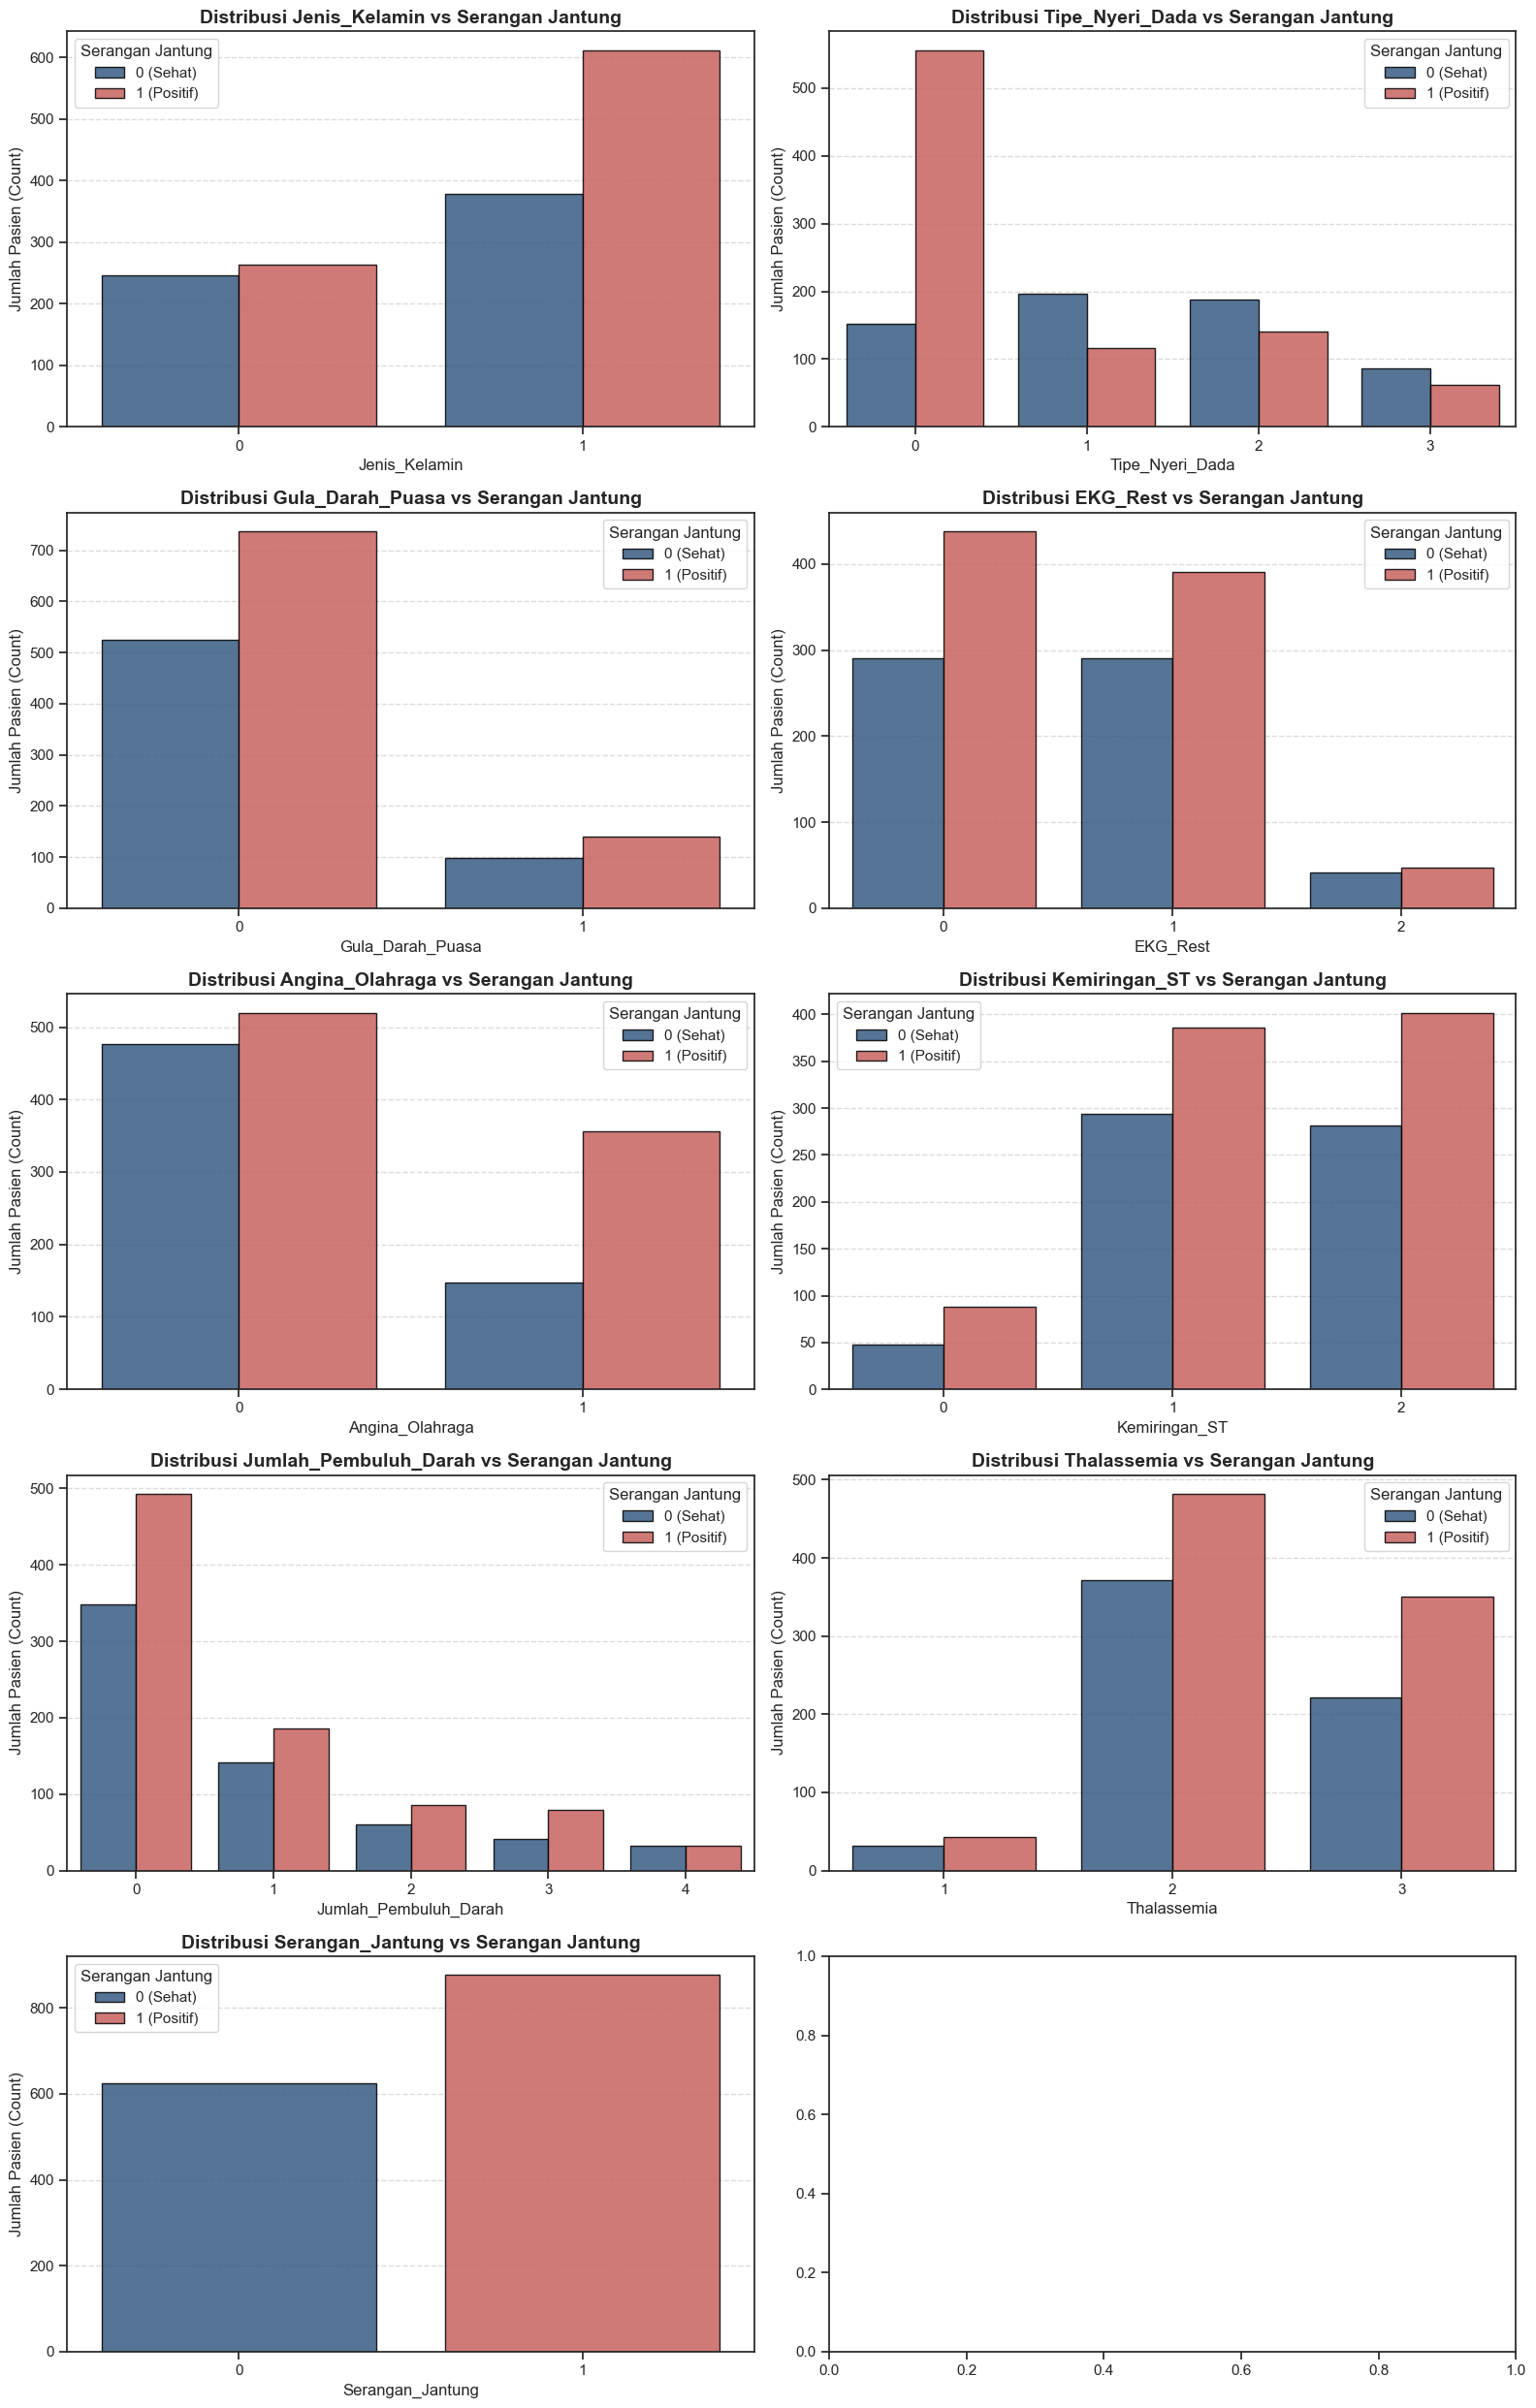

In [8]:
# Mengatur tema visualisasi dan membuat subplots grid 4x2
sns.set_theme(style="ticks")
fig, axes = plt.subplots(5, 2, figsize=(16, 25))
axes = axes.flatten()
# Palet warna kustom untuk membedakan target (0 = Sehat/Biru, 1 = Serangan Jantung/Merah)
colors = {0: "#2b5c8f", 1: "#d9534f"}
#Melakukan perulangan untuk menggambar countplot di setiap fitur kategorikal
for i, feature in enumerate(feature_categori):
    sns.countplot(data=df,x=feature,hue="Serangan_Jantung",ax= axes[i],palette=colors,edgecolor="black",alpha=0.85,)
    axes[i].set_title(f"Distribusi {feature} vs Serangan Jantung",fontsize=14,fontweight="bold",)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Jumlah Pasien (Count)", fontsize=12)
    axes[i].legend(title="Serangan Jantung", labels=["0 (Sehat)", "1 (Positif)"])
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)
#Mengatur tata letak agar rapi dan menyimpan gambar ke berkas lokal
plt.tight_layout()
plt.show

In [9]:
Q1 = df[feauter_numerik].quantile(0.25)
Q3 = df[feauter_numerik].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#.any(axis=1) => "Ambil baris tersebut jika ada MINIMAL SATU kolom saja yang mendeteksi outlier."
outliers = df.loc[((df[feauter_numerik] < lower_bound) | (df[feauter_numerik] > upper_bound)).any(axis=1)]

print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')

Jumlah outliers terdeteksi: 0


In [10]:
scaler = StandardScaler()
df[feauter_numerik] = scaler.fit_transform(df[feauter_numerik])
df[feauter_numerik].head()

,Usia,Tekanan_Darah_Rest,Kolesterol,Detak_Jantung_Max,Oldpeak_ST,BMI
0,0.814243,1.448084,-1.334858,0.512778,-1.469722,0.292643
1,1.677071,-0.951547,-1.468588,1.065661,1.155114,0.467130
2,0.150530,0.659164,0.537365,0.907694,1.210962,-0.437034
3,-0.778668,0.790651,-0.917935,1.091989,1.155114,0.816106
4,1.079729,1.711058,-1.397790,-0.171745,1.043419,-0.008746


In [11]:
# df.to_csv("dataset_serangan_jantung_clean.csv", index=False)